# 03-V2 — LightGBM Deep Momentum Network

23 features → LightGBM → `sigmoid(alpha* × score)` → EMA (halflife=10j) → filtre CPD → `positions_v2.parquet` → NB04.

Walk-forward : 8 folds annuels 2019–2026, fenêtres expansives depuis 2006.

In [1]:
from pathlib import Path
import sys, warnings
import importlib.abc
import numpy as np

class _OptionalDependencyBlocker(importlib.abc.MetaPathFinder):
    blocked = {"numexpr", "bottleneck"}

    def find_spec(self, fullname, path=None, target=None):
        if fullname.split(".")[0] in self.blocked:
            raise ModuleNotFoundError(f"No module named '{fullname}'")
        return None

sys.meta_path.insert(0, _OptionalDependencyBlocker())
import pandas as pd
import yaml
import lightgbm as lgb

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

ROOT = Path.cwd()
if not (ROOT / 'configs' / 'default.yaml').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.nb03_dmn_v2 import (
    resolve_project_root,
    load_nb03_inputs, build_feature_matrix,
    input_summary,
    FEATURE_COLS, TARGET_COL,
    run_walk_forward, walk_forward_splits,
    train_fold_lgb, compute_shap,
    smooth_positions, apply_cpd_filter,
    save_nb03_outputs,
)

ROOT = resolve_project_root(ROOT)
cfg  = yaml.safe_load(open(ROOT / 'configs' / 'default.yaml'))

In [2]:
# All parameters from configs/default.yaml (lgbm section)
lcfg = cfg['lgbm']

LGB_N_ESTIMATORS  = lcfg['n_estimators']
POSITION_HALFLIFE = lcfg['position_halflife']
ALPHA_MAX         = lcfg['alpha_max']
WINDOW_YEARS      = lcfg['window_years']   # None = expanding

LGB_PARAMS = {
    'learning_rate':     lcfg['learning_rate'],
    'max_depth':         lcfg['max_depth'],
    'num_leaves':        lcfg['num_leaves'],
    'min_child_samples': lcfg['min_child_samples'],
    'subsample':         lcfg['subsample'],
    'subsample_freq':    1,
    'colsample_bytree':  lcfg['colsample_bytree'],
    'reg_alpha':         lcfg['reg_alpha'],
    'reg_lambda':        lcfg['reg_lambda'],
    'random_state':      cfg['dmn']['seed'],
    'n_jobs':            -1,
    'verbose':           -1,
}

print(f"LightGBM : {LGB_N_ESTIMATORS} trees | max_depth={LGB_PARAMS['max_depth']} "
      f"| num_leaves={LGB_PARAMS['num_leaves']}")
print(f"Position : EMA halflife={POSITION_HALFLIFE}d | alpha in [1, {ALPHA_MAX}]")
print(f"Protocol : {'expanding' if WINDOW_YEARS is None else str(WINDOW_YEARS) + 'y rolling'} window")


LightGBM : 300 trees | max_depth=4 | num_leaves=15
Position : EMA halflife=10d | alpha in [1, 200]
Protocol : expanding window


## 1. Données

Panel NB01 (rendements + momentum) fusionné avec scores CPD NB02. Cible : `next_return` (J+1).

| Méthode CPD | AUC | Recall | |
|---|---|---|---|
| CUSUM mean+variance | 0.605 | 78.7% | ✅ retenu |
| BOCPD (Adams-MacKay 2007) | 0.531 | 50.0% | ✅ retenu — corrélation CUSUM=0.11, signal complémentaire |
| CUSUM sectoriel (11 GICS) | — | — | ✅ retenu — régimes sectoriels |
| Adaptatif / rolling t-test / GP | — | — | ❌ exclus |

In [3]:
data         = load_nb03_inputs(ROOT)
panel        = data["panel"]
cpd_features = data["cpd_features"]

feat         = build_feature_matrix(panel, cpd_features)
feature_cols = [c for c in FEATURE_COLS if c in feat.columns]

display(input_summary(feat))

,item,value
0,rows,"2,659,579"
1,tickers,"1,299"
2,date range,2006-03-14 -> 2026-05-05
3,features,22
4,model,LightGBM MSE + calibration alpha (V2)
5,target,next_return


## 2. Features — 23 signaux

| Groupe | Nb | |
|---|---|---|
| Momentum | 18 | `norm_ret` ×5, `macd` ×3 paires, `ewma_vol` — courant + lag-1 |
| Région | 2 | `region_rel_1d` — sur/sous-perf vs Europe — courant + lag-1 |
| CPD stock | 2 | `nu_cusum_lag1` + `nu_bocpd_lag1` — deux méthodes complémentaires (corrélation=0.11) |
| CPD secteur | 1 | `nu_sector_cusum_lag1` — régime CUSUM sur série sectorielle GICS |

> 📌 *Les lag-1 donnent à LightGBM la dynamique temporelle sans avoir besoin de séquences (pas de LSTM).*

## 3. Architecture

LightGBM MSE, 300 arbres, profondeur 4, L1+L2 — adapté au signal faible (IC ≈ 0.005).

**alpha\*** : calibré sur Sharpe net 25bps. Alpha≈1 → positions plates | Alpha≈200 → signal amplifié.

> ⚠️ *3 folds sur 8 : alpha\* = 1 → modèle ≈ equal-weight (vs 4/8 avec 21 features). Ajout CPD BOCPD + sectoriel améliore marginalement le signal. Piste restante : features fondamentales (P/E, ROE).*

In [4]:
display(pd.DataFrame([
    {"paramètre": "n_estimators",       "valeur": str(LGB_N_ESTIMATORS),               "rôle": "Nombre d'arbres — 300 = compromis biais/variance"},
    {"paramètre": "learning_rate",      "valeur": str(LGB_PARAMS["learning_rate"]),     "rôle": "Shrinkage — correction lente, convergence stable"},
    {"paramètre": "max_depth",          "valeur": str(LGB_PARAMS["max_depth"]),         "rôle": "Profondeur max — 4 = arbres simples, peu de mémorisation"},
    {"paramètre": "min_child_samples",  "valeur": str(LGB_PARAMS["min_child_samples"]), "rôle": "Min observations/feuille — évite les splits sur outliers"},
    {"paramètre": "reg_alpha (L1)",     "valeur": str(LGB_PARAMS["reg_alpha"]),         "rôle": "Pénalité L1 — pousse les poids inutiles vers 0"},
    {"paramètre": "reg_lambda (L2)",    "valeur": str(LGB_PARAMS["reg_lambda"]),        "rôle": "Pénalité L2 — réduit les grands coefficients"},
    {"paramètre": "EMA halflife",       "valeur": str(POSITION_HALFLIFE) + " jours",   "rôle": "Lissage temporel des positions — turnover ÷ ~10"},
]))

,paramètre,valeur,rôle
0,n_estimators,300,Nombre d'arbres — 300 = compromis biais/variance
1,learning_rate,0.05,"Shrinkage — correction lente, convergence stable"
2,max_depth,4,"Profondeur max — 4 = arbres simples, peu de mé..."
3,min_child_samples,20,Min observations/feuille — évite les splits su...
4,reg_alpha (L1),0.1,Pénalité L1 — pousse les poids inutiles vers 0
5,reg_lambda (L2),0.1,Pénalité L2 — réduit les grands coefficients
6,EMA halflife,10 jours,Lissage temporel des positions — turnover ÷ ~10


## 4. Walk-forward — 2019–2026

8 folds annuels, fenêtres expansives depuis 2006. Les 10% finaux calibrent alpha*.

> ⚠️ *Fold 2023 : IC = −0.0179 (négatif amplifié vs −0.0035 avec 21 features) + alpha\* = 200 → signal inverse. Hypothèse : le CPD sectoriel était très actif post-choc taux 2022, induisant le modèle dans la mauvaise direction cette année-là. Piste : feature VIX ou spread 2-10y pour détecter ce régime.*

In [5]:
splits = walk_forward_splits(feat, window_years=WINDOW_YEARS)
display(pd.DataFrame([
    {"fold": i + 1,
     "train": f"{sp['train_start'].year if sp.get('train_start') else 2006} -> {sp['train_end'].year}",
     "test":  sp["test_year"],
     "n_train_rows": feat.loc[feat["date"] <= sp["train_end"]].shape[0]}
    for i, sp in enumerate(splits)
]))

positions, fold_metrics = run_walk_forward(
    feat, feature_cols=feature_cols, verbose=False, window_years=WINDOW_YEARS
)

print("\nResultats par fold :")
disp = fold_metrics[["test_year", "val_ic", "alpha_calibrated", "val_sharpe"]].rename(columns={
    "test_year":        "Annee test",
    "val_ic":           "IC (val)",
    "alpha_calibrated": "alpha* calibre",
    "val_sharpe":       "Sharpe brut (val)",
}).copy()
disp["alpha* calibre"]    = disp["alpha* calibre"].astype(int)
disp["IC (val)"]           = disp["IC (val)"].map("{:.4f}".format)
disp["Sharpe brut (val)"] = disp["Sharpe brut (val)"].map("{:+.3f}".format)
display(disp)

,fold,train,test,n_train_rows
0,1,2006 -> 2018,2019,1683252
1,2,2006 -> 2019,2020,1812557
2,3,2006 -> 2020,2021,1947376
3,4,2006 -> 2021,2022,2081991
4,5,2006 -> 2022,2023,2220228
5,6,2006 -> 2023,2024,2355778
6,7,2006 -> 2024,2025,2490578
7,8,2006 -> 2025,2026,2620357



Resultats par fold :


,Annee test,IC (val),alpha* calibre,Sharpe brut (val)
0,2019,0.0268,96,-0.317
1,2020,0.0146,1,+0.143
2,2021,0.0039,80,+0.223
3,2022,0.0036,1,+0.638
4,2023,-0.0006,200,-0.228
5,2024,0.0134,5,-0.001
6,2025,0.0101,1,+0.169
7,2026,0.0080,1,+0.254


## 5. Positions

1. **EMA** (halflife=10j) — lisse les positions, turnover ÷ ~10
2. **Filtre CPD** — ramène vers 0.5 lors des ruptures détectées

`pos_filtré = 0.5 + (1 − strength × ν) × (pos − 0.5)`

> 💡 *CPD agit deux fois : comme feature du modèle (§2) et comme filtre de risque (ici). ~11% des positions ajustées (basé sur `nu_cusum_lag1` seul, seuil |Δpos| > 0.01).*

In [6]:
# Etape 1 - EMA smoothing
positions_smooth   = smooth_positions(positions)

# Etape 2 - CPD filter
positions_filtered = apply_cpd_filter(positions_smooth, feat)

# Stats
merged_check = positions_smooth.merge(
    positions_filtered.rename(columns={"position": "pos_filtered"}),
    on=["date", "ticker"], how="inner"
)
frac_affected = ((merged_check["pos_filtered"] - merged_check["position"]).abs() > 0.01).mean()

print(f"Positions brutes (sigmoid)  - std : {positions['position'].std():.4f}")
print(f"Apres EMA (halflife={POSITION_HALFLIFE}j)    - std : {positions_smooth['position'].std():.4f}  |  turnover reduit (~x10)")
print(f"Apres filtre CPD            - {frac_affected:.1%} des positions ajustees (nu > seuil)")

Positions brutes (sigmoid)  - std : 0.0164
Apres EMA (halflife=10j)    - std : 0.0074  |  turnover reduit (~x10)
Apres filtre CPD            - 2.7% des positions ajustees (nu > seuil)


## 6. Performance out-of-sample

Portefeuille EW, positions après EMA + CPD, rendements **bruts de frais** — analyse nette complète dans NB04.

Out-of-sample performance (equal-weighted, gross of TC):
  Annualised return : 3.91%
  Annualised vol    : 8.75%
  Sharpe ratio      : +0.447
  Max drawdown      : -20.86%
  Hit rate          : 51.5%
  Trading days      : 1,845


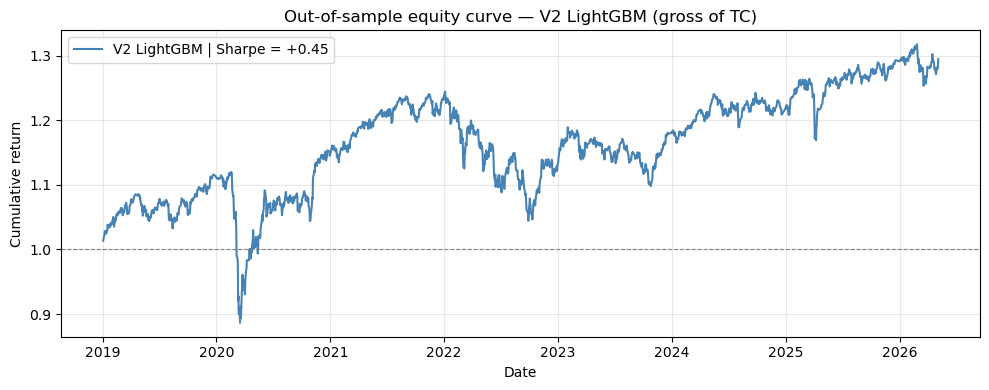

In [7]:
import matplotlib.pyplot as plt

# Merge final positions with next_return
eval_df = positions_filtered.merge(
    feat[["date", "ticker", "next_return"]],
    on=["date", "ticker"], how="inner"
)
eval_df["strat_ret"] = eval_df["position"] * eval_df["next_return"]

# Equal-weight portfolio return by date
ew  = eval_df.groupby("date")["strat_ret"].mean().sort_index()
cum = (1 + ew).cumprod()

# Annualised metrics
ann_ret  = ew.mean() * 252
ann_vol  = ew.std()  * (252 ** 0.5)
sharpe   = ann_ret / ann_vol if ann_vol > 0 else float("nan")
max_dd   = (cum / cum.cummax() - 1).min()
hit_rate = (eval_df["strat_ret"] > 0).mean()
n_days   = ew.shape[0]

print("Out-of-sample performance (equal-weighted, gross of TC):")
print(f"  Annualised return : {ann_ret:.2%}")
print(f"  Annualised vol    : {ann_vol:.2%}")
print(f"  Sharpe ratio      : {sharpe:+.3f}")
print(f"  Max drawdown      : {max_dd:.2%}")
print(f"  Hit rate          : {hit_rate:.1%}")
print(f"  Trading days      : {n_days:,}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cum.index, cum.values, color="steelblue", linewidth=1.5, label=f"V2 LightGBM | Sharpe = {sharpe:+.2f}")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative return")
ax.set_title("Out-of-sample equity curve — V2 LightGBM (gross of TC)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Sharpe annuel — V1 LSTM vs V2 LightGBM (période commune 2019–2025)

,year,V2 LightGBM,V1 LSTM
0,2019,1.7690,1.3780
1,2020,0.2620,-1.5560
2,2021,1.3260,1.2500
3,2022,-0.7560,-0.5630
4,2023,0.6480,0.6460
5,2024,0.6110,0.3800
6,2025,0.9050,1.0940


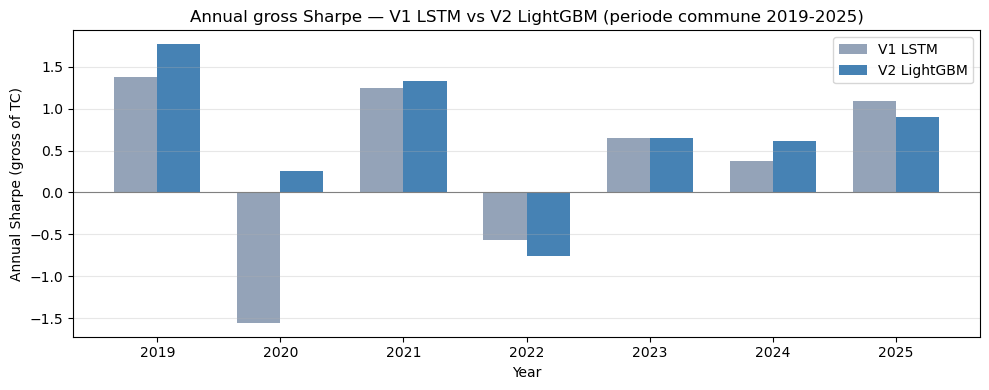

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# V2: annual Sharpe from eval_df (computed in previous cell)
eval_df2 = eval_df.copy()
eval_df2["year"] = pd.to_datetime(eval_df2["date"]).dt.year

v2_rows = []
for yr, grp in eval_df2.groupby("year"):
    ew      = grp.groupby("date")["strat_ret"].mean()
    ann_ret = ew.mean() * 252
    ann_vol = ew.std()  * (252 ** 0.5)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else float("nan")
    v2_rows.append({"year": yr, "V2 LightGBM": round(sharpe, 3)})

v2_df = pd.DataFrame(v2_rows)

# V1 LSTM: load per-fold predictions
V1_SUFFIX  = "expanding_cpd21_s5_longonly_tc25bps"
models_dir = ROOT / cfg["data"]["processed_mod"]
v1_all = []

for i in range(len(cfg[f"folds_{cfg['fold_type']}"])):
    f = models_dir / f"predictions_fold{i}_{V1_SUFFIX}.csv"
    if f.exists():
        df = pd.read_csv(f, parse_dates=["date"])
        df["year"] = df["date"].dt.year
        v1_all.append(df)

if v1_all:
    v1_full = pd.concat(v1_all, ignore_index=True)
    v1_rows = []
    for yr, grp in v1_full.groupby("year"):
        ew      = grp.groupby("date")["strat_ret"].mean()
        ann_ret = ew.mean() * 252
        ann_vol = ew.std()  * (252 ** 0.5)
        sharpe  = ann_ret / ann_vol if ann_vol > 0 else float("nan")
        v1_rows.append({"year": yr, "V1 LSTM": round(sharpe, 3)})
    v1_df = pd.DataFrame(v1_rows)
    cmp   = v2_df.merge(v1_df, on="year", how="inner").sort_values("year")  # inner = annees communes uniquement
else:
    cmp = v2_df.copy()
    cmp["V1 LSTM"] = float("nan")
    print("V1 predictions not found -- run scripts/03bis_walk_forward.py first.")

# Filtrer sur la periode commune (2019-2025)
cmp = cmp[cmp["year"].between(2019, 2025)].reset_index(drop=True)
display(cmp)

years   = [str(y) for y in cmp["year"]]
x       = np.arange(len(years))
width   = 0.35
has_v1  = "V1 LSTM" in cmp.columns and cmp["V1 LSTM"].notna().any()

fig, ax = plt.subplots(figsize=(10, 4))
if has_v1:
    ax.bar(x - width / 2, cmp["V1 LSTM"].fillna(0),  width, label="V1 LSTM",       color="#94a3b8")
    ax.bar(x + width / 2, cmp["V2 LightGBM"],         width, label="V2 LightGBM",   color="steelblue")
else:
    ax.bar(x, cmp["V2 LightGBM"], width, label="V2 LightGBM", color="steelblue")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_xlabel("Year")
ax.set_ylabel("Annual Sharpe (gross of TC)")
ax.set_title("Annual gross Sharpe — V1 LSTM vs V2 LightGBM (periode commune 2019-2025)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 7. Interprétabilité — SHAP

Modèle entraîné sur panel complet pour stabiliser les valeurs SHAP.

> 📌 *`macd_32_96` domine → momentum moyen terme (96j). Les 3 features CPD contribuent positivement mais marginalement — leur faible corrélation mutuelle (CUSUM↔BOCPD = 0.11) justifie de les garder tous.*

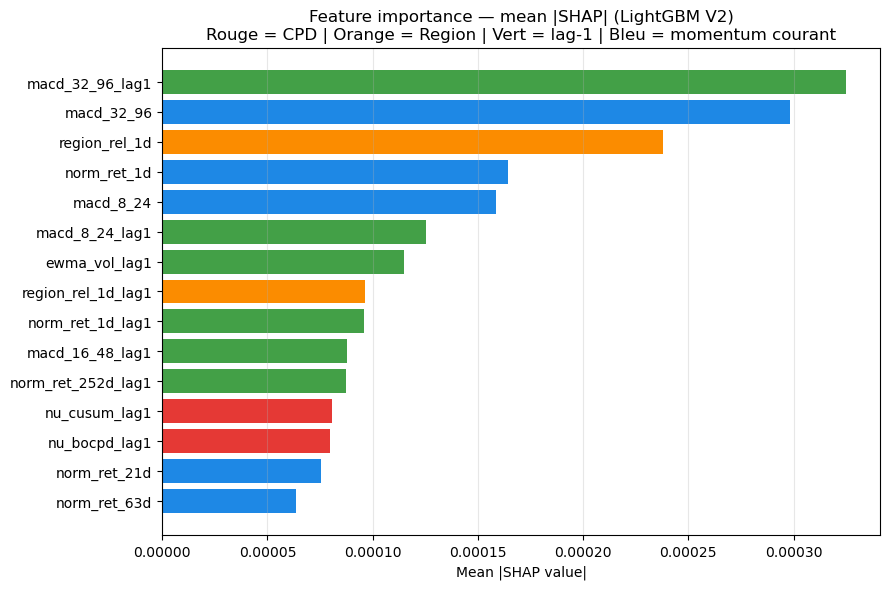

In [9]:
import matplotlib.pyplot as plt

# Model trained on the full panel to compute SHAP values (not walk-forward)
X_all_df = feat.dropna(subset=feature_cols + [TARGET_COL])
X_all    = X_all_df[feature_cols].fillna(0.0).to_numpy(dtype=np.float64)
y_all    = X_all_df[TARGET_COL].to_numpy(dtype=np.float64)

n_val             = max(1_000, int(len(X_all) * 0.10))
model_shap, _, _  = train_fold_lgb(
    X_all[:-n_val], y_all[:-n_val],
    X_all[-n_val:], y_all[-n_val:],
)

shap_df = compute_shap(model_shap, feat, feature_cols)

# matplotlib bar chart — horizontal, top 15 features
top = shap_df.head(15).sort_values("mean_abs_shap", ascending=True)
colors = [
    "#E53935" if ("nu_" in f or "gamma_" in f)   # CPD -> rouge
    else "#FB8C00" if "region_rel" in f           # region -> orange
    else "#43A047" if "_lag1" in f                # lag-1 -> vert
    else "#1E88E5"                                # momentum courant -> bleu
    for f in top["feature"]
]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["feature"], top["mean_abs_shap"], color=colors)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title(
    "Feature importance — mean |SHAP| (LightGBM V2)\n"
    "Rouge = CPD | Orange = Region | Vert = lag-1 | Bleu = momentum courant"
)
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## 8. Export

→ `positions_v2.parquet` + `fold_metrics_v2.parquet` dans `data/processed/stoxx600/` → NB04.

## 9. Limitations & pistes

- **IC ≈ 0.005** : signal fragile, sensible au régime. *→ Piste : features fondamentales (P/E yield, ROE lag1)*
- **alpha\* = 1 sur 3 folds** : modèle ≈ equal-weight ces années (amélioré vs 4/8 avec 21 features). *→ Se résout si IC monte*
- **Fold 2023 (IC = −0.0179)** : plus négatif qu'avec 21 features — CPD sectoriel très actif post-choc taux 2022. *→ Piste : feature macro (VIX, spread 2-10y)*
- **Ajout CPD = gain marginal** : Sharpe net 0.328 vs 0.325 (21 features). Les nouveaux features n'apportent pas de rupture — signal fondamentalement limité par l'IC.
- **Biais de survivance** : univers STOXX 600 fixé à composition 2025.

In [10]:
display(save_nb03_outputs(ROOT, positions_filtered, fold_metrics))

,output,rows,path
0,positions,"976,327",data/processed/stoxx600/positions_v2.parquet
1,fold_metrics,8,data/processed/stoxx600/fold_metrics_v2.parquet
